In [1]:
import pandas as pd
wine = pd.read_csv("https://peter.butka.website.tuke.sk/test/winequality.csv")

In [2]:
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


<AxesSubplot:xlabel='quality', ylabel='Count'>

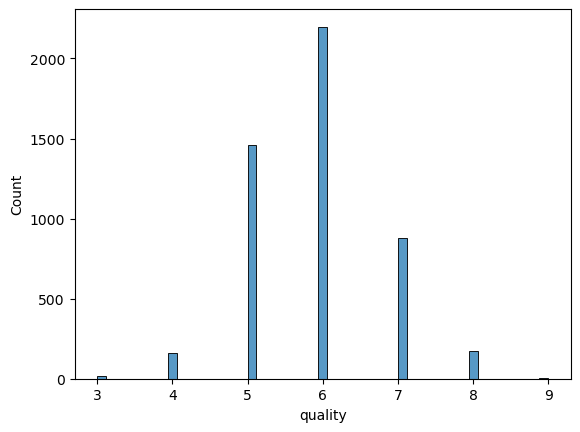

In [3]:
import seaborn as sns
sns.histplot(data=wine, x="quality")

In [4]:
correlation_matrix = wine.corr()
print(correlation_matrix)

                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000         -0.022697     0.289181   
volatile acidity          -0.022697          1.000000    -0.149472   
citric acid                0.289181         -0.149472     1.000000   
residual sugar             0.089021          0.064286     0.094212   
chlorides                  0.023086          0.070512     0.114364   
free sulfur dioxide       -0.049396         -0.097012     0.094077   
total sulfur dioxide       0.091070          0.089261     0.121131   
density                    0.265331          0.027114     0.149503   
pH                        -0.425858         -0.031915    -0.163748   
sulphates                 -0.017143         -0.035728     0.062331   
alcohol                   -0.120881          0.067718    -0.075729   
quality                   -0.113663         -0.194723    -0.009209   

                      residual sugar  chlorides  free sulfur dioxide  \
fixed acidity    

In [7]:
train_data = wine.sample(frac=0.7)
test_data = wine.drop(train_data.index)

In [10]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(train_data[['alcohol', 'pH', 'sulphates', 'citric acid', 'free sulfur dioxide']], train_data['quality'])

LinearRegression()

In [12]:
predicted_values = model.predict(test_data[['alcohol', 'pH', 'sulphates', 'citric acid', 'free sulfur dioxide']])
print(predicted_values)

[5.50109859 6.18770014 5.89368757 ... 5.60804605 6.0365369  5.390447  ]


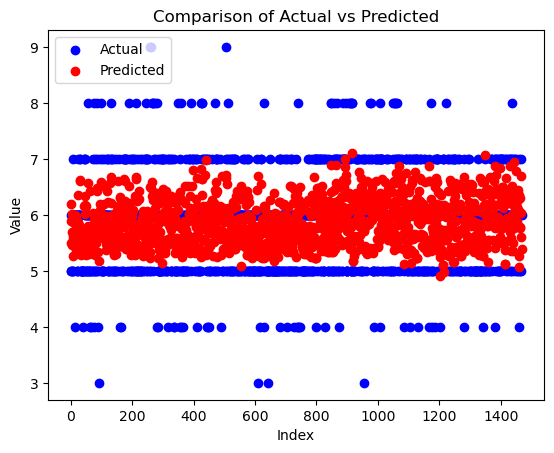

In [21]:
import matplotlib.pyplot as plt
plt.scatter(range(len(test_data['quality'])), test_data['quality'], color='blue', label='Actual', marker='o')
plt.scatter(range(len(predicted_values)), predicted_values, color='red', label='Predicted', marker='o')
plt.xlabel('Index')  # Подпись оси x
plt.ylabel('Value')  # Подпись оси y
plt.title('Comparison of Actual vs Predicted')  # Заголовок графика
plt.legend(loc='upper left')  # Расположение легенды
plt.show()
